# Credit Card Approval Prediction System

## Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to understand the credit card approval dataset through exploratory data analysis (EDA). This includes examining the dataset structure, identifying missing values and duplicates, analyzing feature distributions, and visualizing relationships among variables to gain insights before preprocessing and model building.

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

plt.style.use("ggplot")

## Load Dataset

In [20]:
import pandas as pd

application_df = pd.read_csv("../dataset/application_record.csv")
credit_df = pd.read_csv("../dataset/credit_record.csv")

print(application_df)
print(credit_df)

             ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0       5008804           M            Y               Y             0   
1       5008805           M            Y               Y             0   
2       5008806           M            Y               Y             0   
3       5008808           F            N               Y             0   
4       5008809           F            N               Y             0   
...         ...         ...          ...             ...           ...   
438552  6840104           M            N               Y             0   
438553  6840222           F            N               N             0   
438554  6841878           F            N               N             0   
438555  6842765           F            N               Y             0   
438556  6842885           F            N               Y             0   

        AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0               427500.0      

##Display Shapes

In [21]:
print("Application Dataset Shape :", application_df.shape)
print("Credit Dataset Shape :", credit_df.shape)

Application Dataset Shape : (438557, 18)
Credit Dataset Shape : (1048575, 3)


##Display First Five Records

In [22]:
application_df.head()
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


##Dataset Information

In [23]:
application_df.info()
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

##Statistical Summary

In [24]:
application_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


##Missing Values

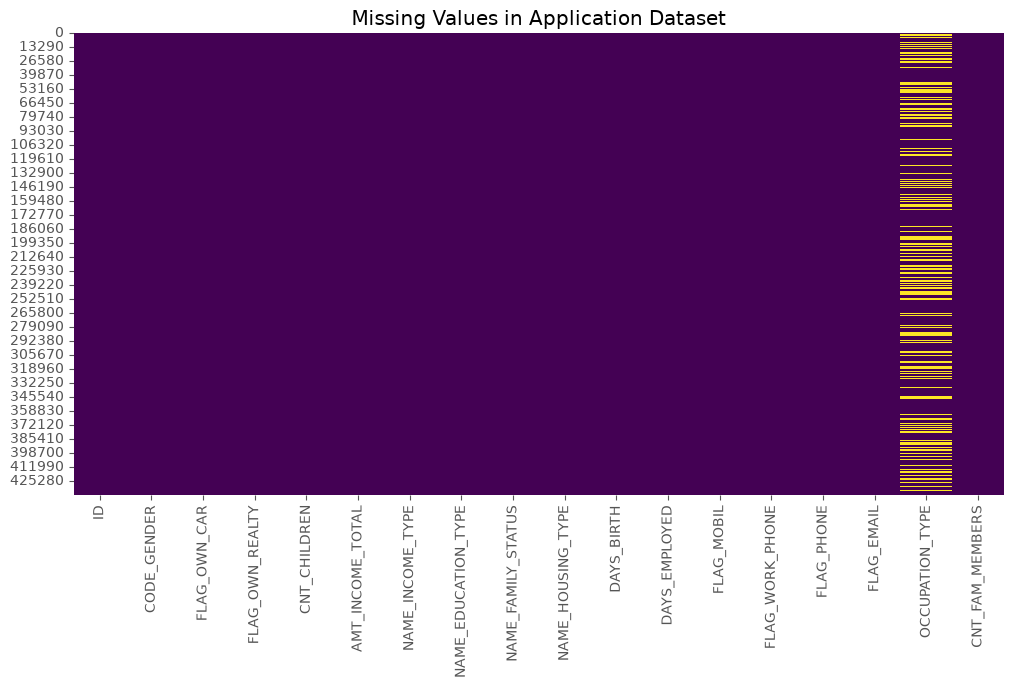

In [25]:
application_df.isnull().sum()
credit_df.isnull().sum()

#Visualize missing values:

plt.figure(figsize=(12,6))
sns.heatmap(application_df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values in Application Dataset")
plt.show()

##Duplicate Records

In [26]:
print("Application Duplicate Rows:",
      application_df.duplicated().sum())

print("Credit Duplicate Rows:",
      credit_df.duplicated().sum())

Application Duplicate Rows: 0
Credit Duplicate Rows: 0


##Gender Distribution

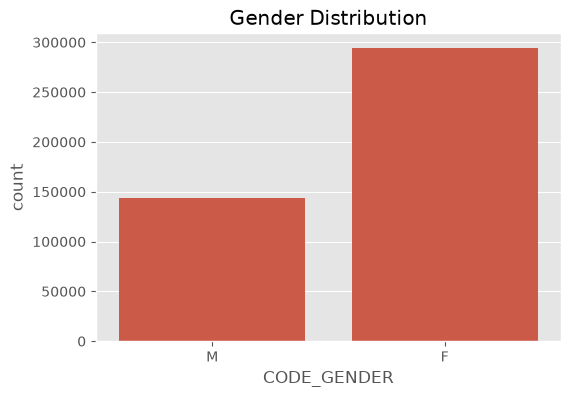

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="CODE_GENDER",
    data=application_df
)

plt.title("Gender Distribution")
plt.show()

##Income Type Distribution

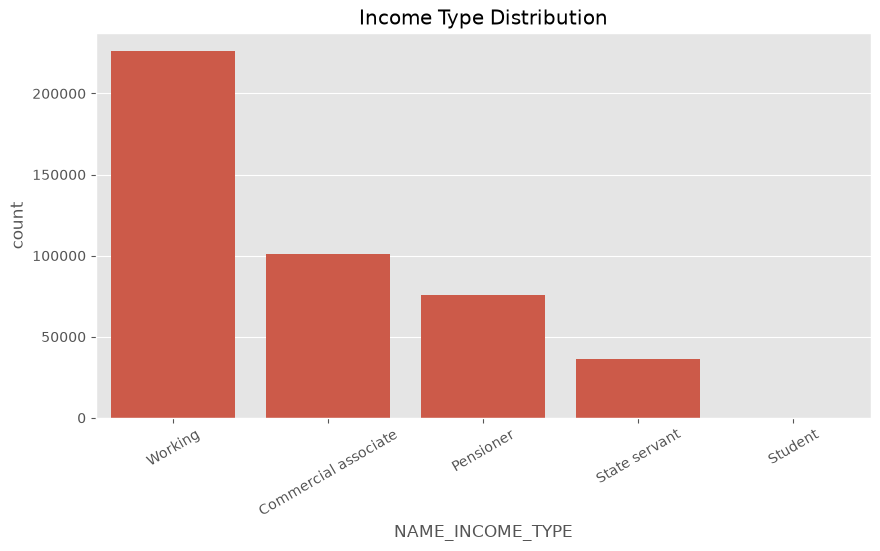

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="NAME_INCOME_TYPE",
    data=application_df
)

plt.xticks(rotation=30)
plt.title("Income Type Distribution")
plt.show()

##Education Distribution

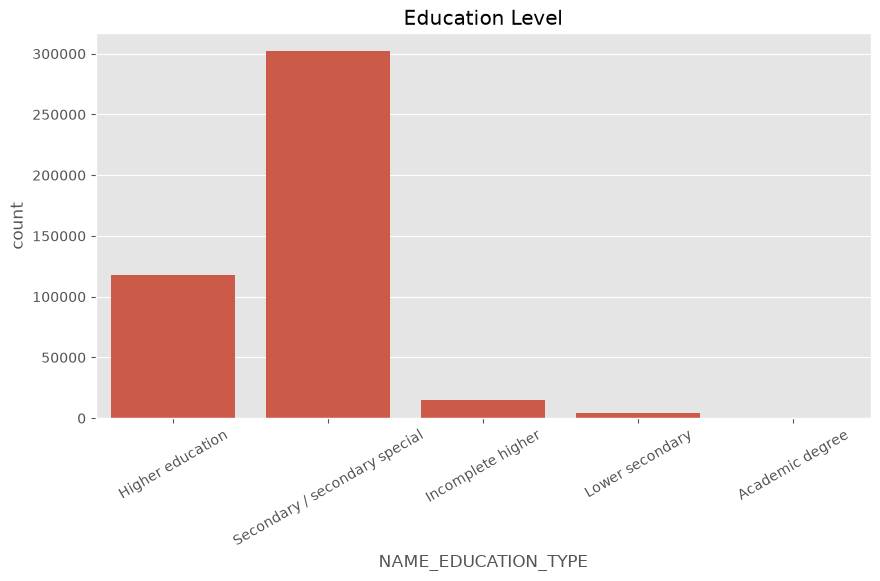

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="NAME_EDUCATION_TYPE",
    data=application_df
)

plt.xticks(rotation=30)
plt.title("Education Level")
plt.show()

##Family Status

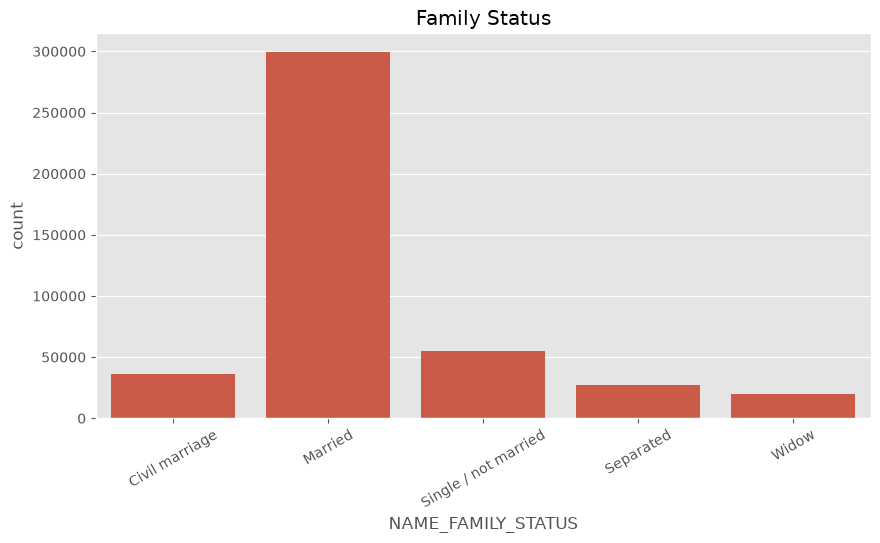

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="NAME_FAMILY_STATUS",
    data=application_df
)

plt.xticks(rotation=30)
plt.title("Family Status")
plt.show()

##Housing Type

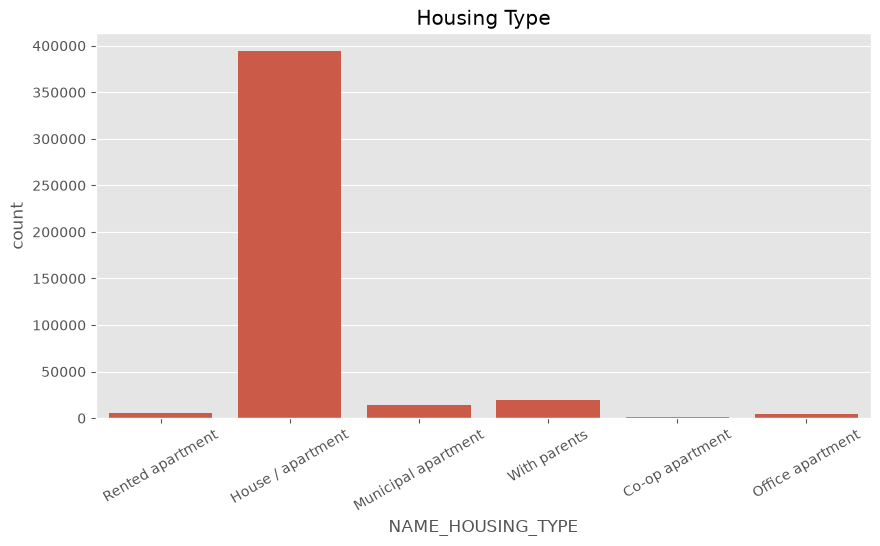

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="NAME_HOUSING_TYPE",
    data=application_df
)

plt.xticks(rotation=30)
plt.title("Housing Type")
plt.show()

##Income Distribution

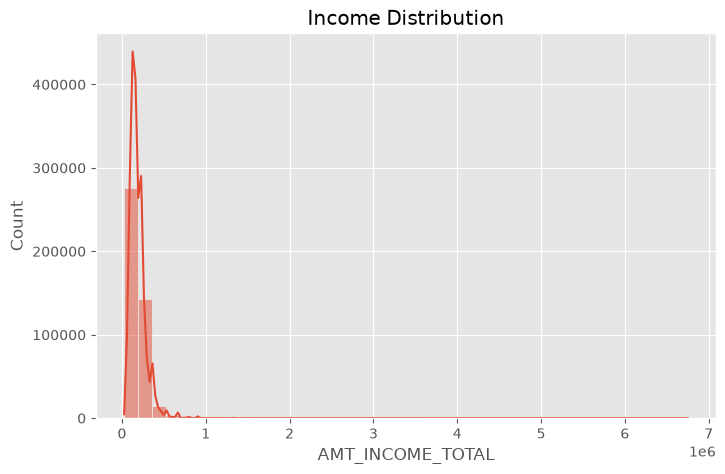

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    application_df["AMT_INCOME_TOTAL"],
    bins=40,
    kde=True
)

plt.title("Income Distribution")
plt.show()

##Age Distribution

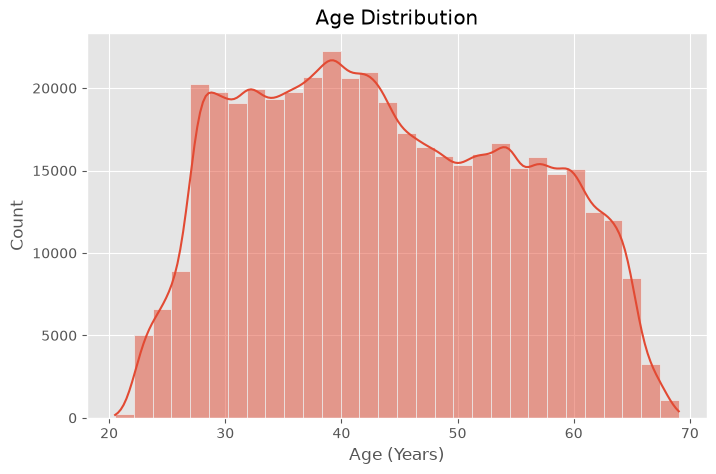

In [33]:
application_df["Age"] = (-application_df["DAYS_BIRTH"]) / 365

plt.figure(figsize=(8,5))

sns.histplot(
    application_df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.show()

##Correlation Heatmap

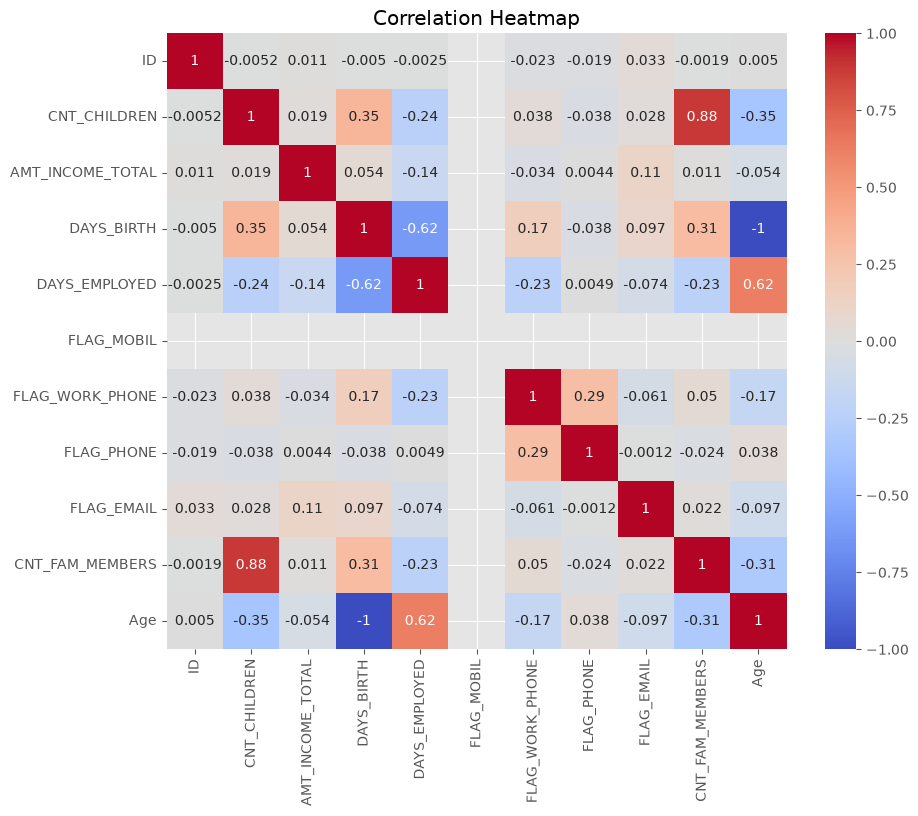

In [34]:
numeric_df = application_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

##Income Boxplot

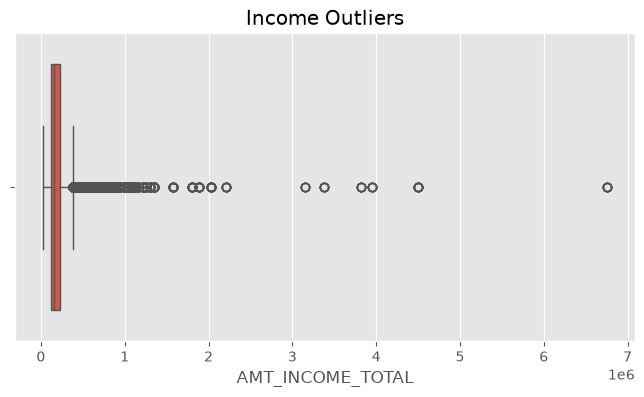

In [35]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=application_df["AMT_INCOME_TOTAL"]
)

plt.title("Income Outliers")
plt.show()

# Conclusion

The Exploratory Data Analysis (EDA) provided valuable insights into the Credit Card Approval dataset.

### Key Findings

- The application dataset contains **438,557 applicant records** with demographic, financial, and employment-related information.
- The credit dataset contains **1,048,575 credit history records**, representing applicants' monthly repayment status.
- The **OCCUPATION_TYPE** column contains missing values and will require preprocessing.
- No significant missing values were found in the credit history dataset.
- The applicant population consists of diverse income types, education levels, family statuses, and housing types.
- The annual income distribution indicates the presence of a few high-income outliers.
- Most applicants belong to the middle-age group, as observed from the age distribution.
- Correlation analysis showed that numerical features have relatively weak linear relationships, making feature engineering an important next step.

### Summary

The exploratory analysis helped identify the dataset structure, data quality issues, and important feature distributions. These insights will be used in the next phase to clean the data, engineer features, create the target variable, and prepare the dataset for training machine learning models for credit card approval prediction.

In [36]:
categorical_columns = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(sorted(application_df[col].dropna().unique()))


CODE_GENDER
['F', 'M']

FLAG_OWN_CAR
['N', 'Y']

FLAG_OWN_REALTY
['N', 'Y']

NAME_INCOME_TYPE
['Commercial associate', 'Pensioner', 'State servant', 'Student', 'Working']

NAME_EDUCATION_TYPE
['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special']

NAME_FAMILY_STATUS
['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow']

NAME_HOUSING_TYPE
['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents']

OCCUPATION_TYPE
['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Waiters/barmen staff']
